#1.Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

sns.set(style="whitegrid")

#2.Load Dataset

In [2]:
df = pd.read_csv("StudentsPerformance.csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#3.Dataset Overview

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
display(df.describe())

Dataset Shape: (1000, 8)

Column Names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

Statistical Summary


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#4.Data Quality Check

In [4]:
print("===== DATA QUALITY REPORT =====")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nUnique Values:")
print(df.nunique())

===== DATA QUALITY REPORT =====

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate Rows:
0

Unique Values:
gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64


#5.Feature Engineering

Create Average Score

In [5]:
df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

Create Pass / Fail column

In [6]:
df['result'] = df['average_score'].apply(
    lambda x: "Pass" if x >= 50 else "Fail"
)

#6.Statistical Analysis

In [7]:
print("Average Math Score:", df['math score'].mean())
print("Average Reading Score:", df['reading score'].mean())
print("Average Writing Score:", df['writing score'].mean())

print("\nMedian Scores:")
print(df[['math score','reading score','writing score']].median())

Average Math Score: 66.089
Average Reading Score: 69.169
Average Writing Score: 68.054

Median Scores:
math score       66.0
reading score    70.0
writing score    69.0
dtype: float64


#7.Correlation Analysis

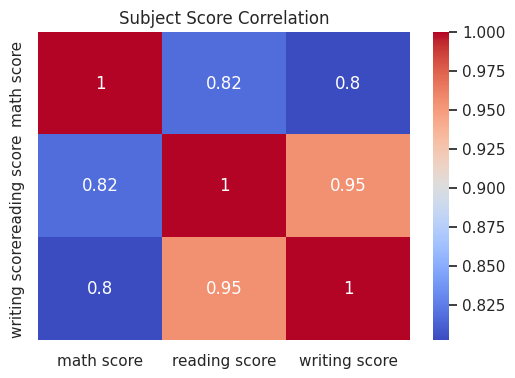

In [8]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[['math score','reading score','writing score']].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Subject Score Correlation")

plt.show()

#8.Visualization

Score Distribution

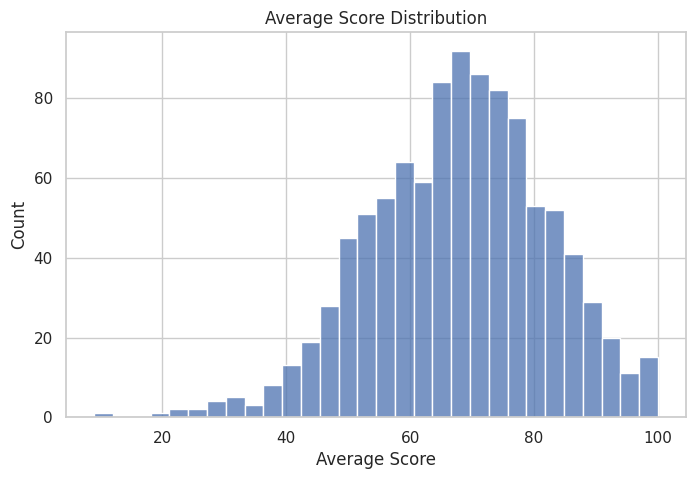

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['average_score'], bins=30)

plt.title("Average Score Distribution")

plt.xlabel("Average Score")

plt.show()

Gender Performance

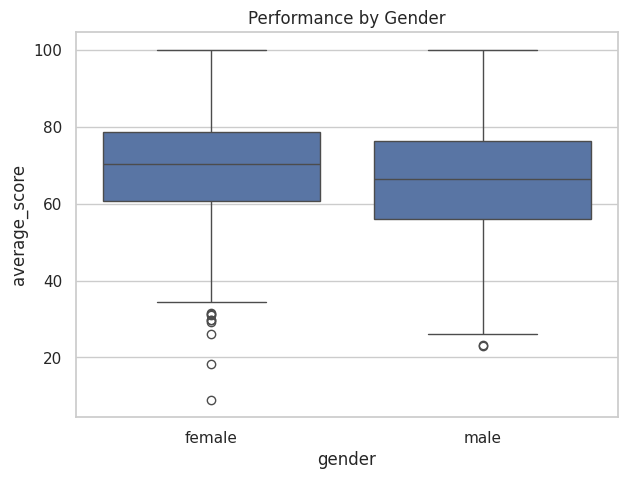

In [10]:
plt.figure(figsize=(7,5))

sns.boxplot(x='gender', y='average_score', data=df)

plt.title("Performance by Gender")

plt.show()

Subject Comparison

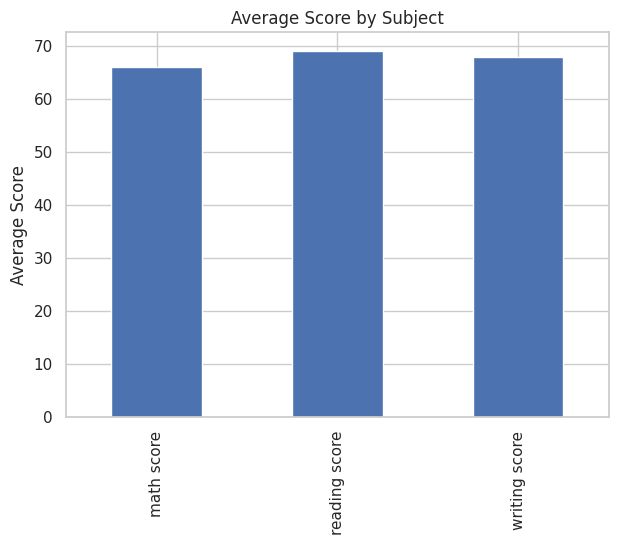

In [11]:
subject_means = df[
    ['math score','reading score','writing score']
].mean()

plt.figure(figsize=(7,5))

subject_means.plot(kind='bar')

plt.title("Average Score by Subject")

plt.ylabel("Average Score")

plt.show()

Test Preparation Impact

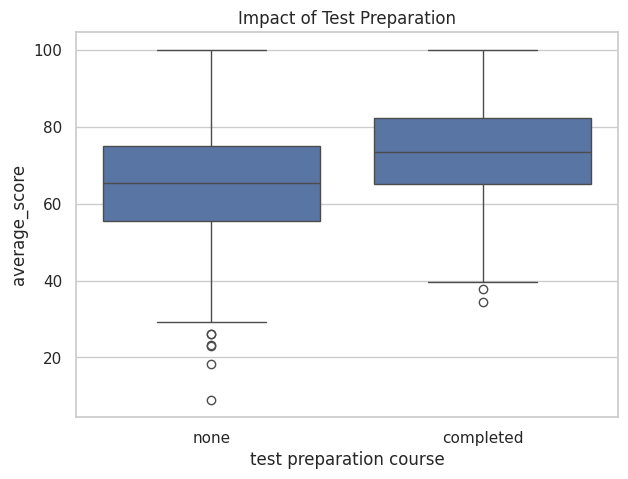

In [12]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='test preparation course',
    y='average_score',
    data=df
)

plt.title("Impact of Test Preparation")

plt.show()

Parental Education Impact

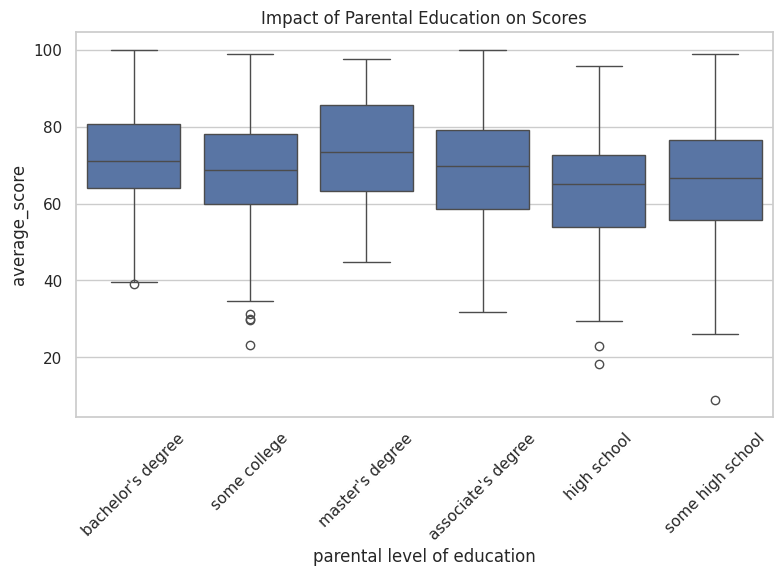

In [13]:
plt.figure(figsize=(9,5))

sns.boxplot(
    x='parental level of education',
    y='average_score',
    data=df
)

plt.xticks(rotation=45)

plt.title("Impact of Parental Education on Scores")

plt.show()

#Pass vs Fail Rate

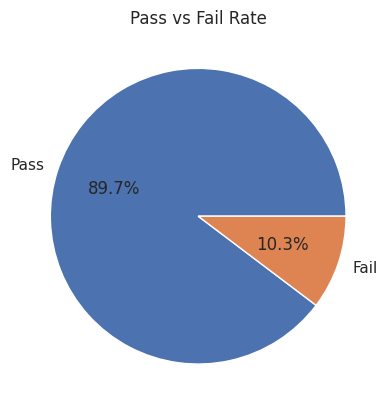

In [14]:
df['result'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Pass vs Fail Rate")

plt.ylabel("")

plt.show()

#Automated Student Performance Report

In [15]:
print("===== STUDENT PERFORMANCE REPORT =====")

print("\nTotal Students:", len(df))

print("\nAverage Score:", df['average_score'].mean())

print("\nPass Rate:")
print(df['result'].value_counts())

print("\nHighest Average Score:")
print(df['average_score'].max())

print("\nLowest Average Score:")
print(df['average_score'].min())

===== STUDENT PERFORMANCE REPORT =====

Total Students: 1000

Average Score: 67.77066666666666

Pass Rate:
result
Pass    897
Fail    103
Name: count, dtype: int64

Highest Average Score:
100.0

Lowest Average Score:
9.0


## Results and Observations

The dataset contains records of student performance across three subjects: Mathematics, Reading, and Writing, along with demographic and background information such as gender, parental level of education, lunch type, and test preparation course.

After performing data exploration and cleaning, it was observed that the dataset contains no missing values and no duplicate records. Statistical analysis revealed that the average scores of students across the three subjects are relatively similar, indicating balanced performance across subjects.

The distribution of average scores shows that most students score within the moderate performance range. Only a small percentage of students fall into extremely high or extremely low score ranges.

Correlation analysis indicates a strong positive relationship between the scores of different subjects. Students who perform well in one subject tend to perform well in the others as well.

Visualization of performance by gender suggests slight differences in average scores between male and female students. The analysis also shows that students who completed the test preparation course tend to achieve higher average scores compared to those who did not.

## Key Insights

Several important insights were discovered from the analysis:

1. Student performance across Mathematics, Reading, and Writing is highly correlated, indicating consistent academic ability across subjects.

2. Students who completed the test preparation course generally achieved higher average scores, suggesting that structured preparation improves academic outcomes.

3. Gender-based analysis indicates slight variations in performance, which may highlight different learning patterns between male and female students.

4. Students whose parents have higher levels of education tend to achieve slightly better academic results, indicating the influence of family educational background.

5. Most students fall within a moderate performance category, meaning targeted support programs could help improve the performance of lower-scoring students.

## Conclusion

This project analyzed student performance data using Python-based data analysis techniques. The analysis included data cleaning, exploratory data analysis, statistical evaluation, and visualization to understand factors influencing student academic performance.

The study revealed strong relationships between subject scores and demonstrated the positive impact of test preparation on academic outcomes. Additionally, demographic factors such as gender and parental education were found to influence student performance to some extent.

Overall, the analysis highlights the importance of preparation, academic support, and family involvement in improving student success. The insights generated from this project can help educators and institutions design more effective learning strategies and support systems for students.